# Run Comparison
This notebook is used in order to compare SEM2DPACK runs

## 1) Import data

### Libraries

In [1]:
#import libraries
import sys
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as anim
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
from mpl_toolkits.mplot3d import Axes3D
from scipy.interpolate import griddata, interp1d

# Set up matplotlib parameters
plt.rcParams['figure.dpi'] = 150
plt.rcParams["animation.html"] = "jshtml"
plt.rcParams['animation.embed_limit'] = 2**128

# Add the parent directory and modules directory to the system path
sys.path.append(os.getcwd()+'/../../')
sys.path.append(os.getcwd()+'/../../modules')

# Import custom modules
from Class_sem2dpack import *
from Stage_module import *
from houches_fb import *

### User Parameters

In [2]:
#--------------------------------------------------
#                 USER PARAMETERS
#--------------------------------------------------

# SEM2DPACK Parameters
direct1 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Batch_L_40_f_05_I_30/Run_00"
direct2 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Batch_L_40_f_05_I_30/Run_01"
direct3 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Batch_L_40_f_05_I_30/Run_02"
direct4 = "C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Batch_L_40_f_05_I_30/Run_03"
is_overburden = False
fmin, fmax = 0.01, 40
SEM1 = sem2dpack(direct1)
SEM2 = sem2dpack(direct2)
SEM3 = sem2dpack(direct3)
SEM4 = sem2dpack(direct4)


# Notebook Parameters
save_figure = False


#--------------------------------------------------

Reading grid information...
Reading header file...
0.01199 1001 1743
--- No extra station ---
*
Reading grid information...
Reading header file...
0.01199 1001 1743
--- No extra station ---
*
Reading grid information...
Reading header file...
0.01199 1001 1743
--- No extra station ---
*
Reading grid information...


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\SEM_Run_Comparison/../..\Class_sem2dpack.py:330: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  line = pd.read_csv(fname, delim_whitespace=True, header=None, nrows=1, dtype=int)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\SEM_Run_Comparison/../..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\SEM_Run_Comparison/../..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version.

Reading header file...
0.01199 1001 1743
--- No extra station ---
*


c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\SEM_Run_Comparison/../..\Class_sem2dpack.py:331: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, names=('x','z'), delim_whitespace=True, header=0, nrows=line.values[0][0])
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\SEM_Run_Comparison/../..\Class_sem2dpack.py:365: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(fname, header=0, nrows=1, dtype=str, delim_whitespace=True)
c:\Users\t.guyonneau\OneDrive - EGIS Group\Documents\GitHub\sem2dpack\JUPYTER\Stage_Theo\SEM_Run_Comparison/../..\Class_sem2dpack.py:375: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Us

### Fault Data

In [3]:
# Vector orientations for fault components
vector_orientations = {}
vector_orientations['Left'] = -1, -1
vector_orientations['Bottom'] = -1, +1
vector_orientations['Right'] = +1, +1


# Function to process fault data for a given SEM object
def process_fault_data(SEM):
    fault_data = {}
    
    # Read fault data for different tags
    read_fault_testing(SEM, ftag=5)
    fault_data['Bottom'] = SEM.fault

    read_fault_testing(SEM, ftag=7)
    fault_data['Right'] = SEM.fault

    read_fault_testing(SEM, ftag=9)
    fault_data['Left'] = SEM.fault

    # Extract the coordinates and slip values for each fault component
    fault_components = {}
    for key, data in fault_data.items():
        X_coord = data['x']
        Z_coord = data['z']
        Slip_1 = data['Slip_1']
        Slip_2 = data['Slip_2']
        orientation = 'Z' if key in ['Left', 'Right'] else 'X'
        Peak_Sliding = np.max( np.max(np.abs(Slip_1), axis=1) )
        Peak_Uplift = np.max( np.max(np.abs(Slip_2), axis=1) )
        fault_components[key] = {
            'X_coord': X_coord, 
            'Z_coord': Z_coord,
            'Slip_1': Slip_1,
            'Slip_2': Slip_2,
            'orientation': orientation,
            'Peak_Sliding': Peak_Sliding,
            'Peak_Uplift': Peak_Uplift
            }
        

    # Extract the time data (assuming it's the same for all components)
    time_fault = fault_data['Left']['Time']

    return fault_components, time_fault

# Process fault data for SEM1 and SEM2
fault_components_SEM1, time_fault_SEM1 = process_fault_data(SEM1)
fault_components_SEM2, time_fault_SEM2 = process_fault_data(SEM2)
fault_components_SEM3, time_fault_SEM3 = process_fault_data(SEM3)
fault_components_SEM4, time_fault_SEM4 = process_fault_data(SEM4)




DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [7] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [9] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [7] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [9] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Normal_Stress
Assigning  Friction
DEBUG :: BC [5] True
Assigning  Slip_1
Assigning  Slip_2
Assigning  Slip_Rate
Assigning  Shear_Stress
Assigning  Norma

### Stations data

In [4]:
def create_path(SEM,comp,t):
        n = f"{t:03d}"
        path = SEM.directory + f'v{comp}_{n}_sem2d.dat'
        return path

def load_field(SEM, comp, t):
    X_Coord, Z_Coord = SEM.mdict["coord"][:,0] , SEM.mdict["coord"][:,1]
    path = create_path(SEM,comp, t)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File {path} does not exist.")
    field = SEM.readField(path)
    return X_Coord, Z_Coord, field

# Konno-Ohmachi smoothening
# Credit: Fabian Bonilla's library :)
def ko(datain,dx=None,bexp=None):
    from math import pi, log10, sin
    y = datain.copy()
    
    nx      = len(y)
    fratio  = 10.0**(2.5/bexp)
    ylis    = np.zeros(nx) #np.arange( nx )
    ylis[0] = y[0]

    for ix in np.arange( 1,nx ):
        fc  = float(ix)*dx
        fc1 = fc/fratio
        fc2 = fc*fratio
        ix1 = int(fc1/dx)
        ix2 = int(fc2/dx) + 1
        if ix1 <= 0:  ix1 = 1
        if ix2 >= nx: ix2 = nx
        a1 = 0.0
        a2 = 0.0
        for j in np.arange( ix1,ix2 ):
            if j != ix:
                c1 = bexp* np.log10(float(j)* dx/ fc)
                c1 = (sin(c1)/c1)**4
                a2 = a2+c1
                a1 = a1+c1*y[j]
            else:
                a2 = a2+1.0
                a1 = a1+y[ix]
        ylis[ix] = a1 / a2

    for ix in np.arange( nx ):
        y[ix] = ylis[ix]
    return y
###

# Computing the fft of the data
def get_FFT(dt=None, data=None):    
    from scipy.fft import fft
    # Spectrum    
    df=1.0/ dt
    N = len(data)
    f = np.linspace(0.0, 1.0/(2.0*dt), N//2)
    spec = abs(fft(data))* dt    
    return f[1:], spec[:int(N/2)-1]

def process_station_data(SEM):
    # Read Input Signal
    input_signal_path = SEM.directory+'/source'
    input_signal = np.genfromtxt(open(input_signal_path,'r'))
    time_input = input_signal[:,0]
    V_input = input_signal[:,1]
    U_input = compute_displacement(V_input.T, time_input).T
    A_input = compute_acceleration(V_input, time_input)

    # Read the X component of stations data
    SEM.read_seismo('x')
    SEM.filter_seismo(fmin, fmax)
    Time_stations = SEM.time
    Vx = SEM.velocity[:,:]
    # Ux = np.zeros(Vx.shape, dtype=np.float32)
    # Ax = np.zeros(Vx.shape, dtype=np.float32)
    # for i in range(Vx.shape[1]):
    #     V = Vx[:,i]
    #     Ux[:,i] = compute_displacement(V, Time_stations)
    #     Ax[:,i] = compute_acceleration(V, Time_stations)
    Ux = compute_displacement(Vx.T, Time_stations).T
    Ax = compute_acceleration(Vx.T, Time_stations).T
        

    # Read the Z component of stations data
    SEM.read_seismo('z')
    SEM.filter_seismo(fmin, fmax)
    Vz = SEM.velocity[:,:]
    # Uz = np.zeros(Vz.shape, dtype=np.float32)
    # Az = np.zeros(Vz.shape, dtype=np.float32)
    # for i in range(Vz.shape[1]):
    #     V = Vz[:,i]
    #     Uz[:,i] = compute_displacement(V, Time_stations)
    #     Az[:,i] = compute_acceleration(V, Time_stations)
    Uz = compute_displacement(Vz.T, Time_stations).T
    Az = compute_acceleration(Vz.T, Time_stations).T

    # Read stations coordinates
    XSTA, ZSTA = SEM.rcoord[:,0], SEM.rcoord[:,1]

    # # Read Snapshots data
    # for i in range(0,Time_stations.size):
    #     try : 
    #         if i==0:
    #             X_snap, Z_snap, Vx_snap = load_field(SEM, 'x', i)
    #             _, _, Vz_snap = load_field(SEM, 'z', i)
    #             Vx_snap = np.expand_dims(Vx_snap, axis=1)
    #             Vz_snap = np.expand_dims(Vz_snap, axis=1)
    #         else :
    #             _, _, Vx_temp = load_field(SEM, 'x', i)
    #             _, _, Vz_temp = load_field(SEM, 'z', i)
    #             Vx_snap = np.concatenate([Vx_snap, np.expand_dims(Vx_temp, axis=1)], axis=1)
    #             Vz_snap = np.concatenate([Vz_snap, np.expand_dims(Vz_temp, axis=1)], axis=1)
    #     except FileNotFoundError:
    #         break 

    Vx_list = []
    Vz_list = []
    valid_indices = []

    # Lecture des snapshots disponibles
    for i in range(Time_stations.size):
        try:
            _, _, Vx_i = load_field(SEM, 'x', i)
            _, _, Vz_i = load_field(SEM, 'z', i)
            Vx_list.append(Vx_i)
            Vz_list.append(Vz_i)
            valid_indices.append(i)
        except FileNotFoundError:
            break  # Arrêt si un fichier est manquant

    # Vérifie qu’on a bien lu au moins un snapshot
    if len(Vx_list) == 0:
        raise RuntimeError("Aucun snapshot lu. Vérifiez les fichiers disponibles.")

    # Empilement vectorisé : shape finale = (nx, nz, nt)
    Vx_snap = np.stack(Vx_list, axis=-1)
    Vz_snap = np.stack(Vz_list, axis=-1)

    # Récupération des coordonnées (à partir du premier snapshot valide)
    X_snap, Z_snap, _ = load_field(SEM, 'x', valid_indices[0])


    # Ux_snap, Uz_snap, Ax_snap, Az_snap = [], [], [], []
    # for s in range(0,Vx_snap.shape[0]):
    #     Vxi, Vzi = Vx_snap[s,:], Vz_snap[s,:]
    #     Uxi, Uzi = compute_displacement(Vxi, Time_stations[:-1]), compute_displacement(Vzi, Time_stations[:-1])
    #     Axi, Azi = compute_acceleration(Vxi, Time_stations[:-1]), compute_acceleration(Vzi, Time_stations[:-1])
    #     Ux_snap.append(Uxi)
    #     Uz_snap.append(Uzi)
    #     Ax_snap.append(Axi)
    #     Az_snap.append(Azi)
    # Ux_snap = np.array(Ux_snap)
    # Uz_snap = np.array(Uz_snap)
    # Ax_snap = np.array(Ax_snap)
    # Az_snap = np.array(Az_snap)
    Ux_snap = compute_displacement(Vx_snap, Time_stations[:-1])
    Uz_snap = compute_displacement(Vz_snap, Time_stations[:-1])
    Ax_snap = compute_acceleration(Vx_snap, Time_stations[:-1])
    Az_snap = compute_acceleration(Vz_snap, Time_stations[:-1])
    


    # Compute PGV and PGA
    PGDx = np.max(np.abs(Ux_snap), axis=1)
    PGDz = np.max(np.abs(Uz_snap), axis=1) 
    PGVx = np.max(np.abs(Vx_snap), axis=1)
    PGVz = np.max(np.abs(Vz_snap), axis=1)
    PGAx = np.max(np.abs(Ax_snap), axis=1)
    PGAz = np.max(np.abs(Az_snap), axis=1)

    # FFT at surface station
    s = get_nearest_station(30, 0, XSTA, ZSTA)
    V_sta = Vx[:, s]
    dt_input = time_input[1] - time_input[0]
    dt_sta = Time_stations[1] - Time_stations[0]

    # Zero-padding to common length
    n_input = len(V_input)
    n_sta = len(V_sta)
    n_fft = 2**int(np.ceil(np.log2(max(n_input, n_sta))))  # next power of 2

    # Pad both signals to same length
    V_input_pad = np.pad(V_input, (0, n_fft - n_input), mode='constant')
    V_sta_pad = np.pad(V_sta, (0, n_fft - n_sta), mode='constant')

    # Compute FFTs
    # FFT_input, freq_input = fourier(V_input_pad, dt_input)
    # FFT_sta, freq_sta = fourier(V_sta_pad, dt_sta)
    freq_input, FFT_input = get_FFT(dt_input, V_input_pad)
    freq_sta, FFT_sta = get_FFT(dt_sta, V_sta_pad)

    epsilon = 1e-5  # Small value to avoid division by zero
    bexp = 25       # Smoothing factor for Konno-Ohmachi smoothing

    # Apply Konno-Ohmachi smoothing
    FFT_input_smooth = ko(FFT_input, dx=freq_input[1] - freq_input[0], bexp=bexp)
    FFT_sta_smooth = ko(FFT_sta, dx=freq_sta[1] - freq_sta[0], bexp=bexp)

    # Ensure same frequency axis for TF computation (they now should match)
    TF = FFT_sta_smooth / np.maximum(FFT_input_smooth, epsilon * np.ones_like(FFT_input_smooth))
    
    
    # Create a dictionary to hold the components of the stations data
    components = {}

    components['time_input'] = time_input
    components['U_input'] = U_input
    components['V_input'] = V_input
    components['A_input'] = A_input

    components['X'] = XSTA
    components['Z'] = ZSTA
    components['Ux'] = Ux
    components['Uz'] = Uz
    components['Vx'] = Vx
    components['Vz'] = Vz
    components['Ax'] = Ax
    components['Az'] = Az

    components['X_snap'] = X_snap
    components['Z_snap'] = Z_snap
    components['Ux_snap'] = Ux_snap
    components['Uz_snap'] = Uz_snap
    components['Vx_snap'] = Vx_snap
    components['Vz_snap'] = Vz_snap
    components['Ax_snap'] = Ax_snap
    components['Az_snap'] = Az_snap
    
    components['PGDx'] = PGDx
    components['PGDz'] = PGDz
    components['PGVx'] = PGVx
    components['PGVz'] = PGVz
    components['PGAx'] = PGAx
    components['PGAz'] = PGAz

    components['FFT_input'] = FFT_input_smooth
    components['FFT_sta'] = FFT_sta_smooth
    components['TF'] = TF
    components['freq_input'] = freq_input
    components['freq_sta'] = freq_sta
    return components, Time_stations

station_components_SEM1, time_stations_SEM1 = process_station_data(SEM1)
station_components_SEM2, time_stations_SEM2 = process_station_data(SEM2)
station_components_SEM3, time_stations_SEM3 = process_station_data(SEM3)
station_components_SEM4, time_stations_SEM4 = process_station_data(SEM4)




Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...
Filtering seissmograms ...


### Grid Data

In [5]:
def process_grid_data(SEM):
    SEM_grid = import_SEM_grid(SEM.directory)
    print("Grid data processed for SEM:", SEM.directory)
    X = SEM_grid['X_grid']
    Z = SEM_grid['Z_grid']
    Vs = SEM_grid['Vs']
    return SEM_grid


# Process grid data for SEM1, SEM2
grid_data_SEM1 = process_grid_data(SEM1)
grid_data_SEM2 = process_grid_data(SEM2)
grid_data_SEM3 = process_grid_data(SEM3)
grid_data_SEM4 = process_grid_data(SEM4)



(25300, 1)
Grid data processed for SEM: C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Batch_L_40_f_05_I_30/Run_00/
(25300, 1)
Grid data processed for SEM: C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Batch_L_40_f_05_I_30/Run_01/
(25300, 1)
Grid data processed for SEM: C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Batch_L_40_f_05_I_30/Run_02/
(25300, 1)
Grid data processed for SEM: C:/Users/t.guyonneau/OneDrive - EGIS Group/Documents/OUTPUT/Batch_L_40_f_05_I_30/Run_03/


## 2) Visualization

### Input Signal

(<Figure size 960x720 with 2 Axes>,
 <Axes: title={'center': 'Input velocity'}, xlabel='Time (s)', ylabel='Velocity (m/s)'>,
 <Axes: title={'center': 'Fourier transform'}, xlabel='Frequency (Hz)', ylabel='Spectral amplitude (m)'>)

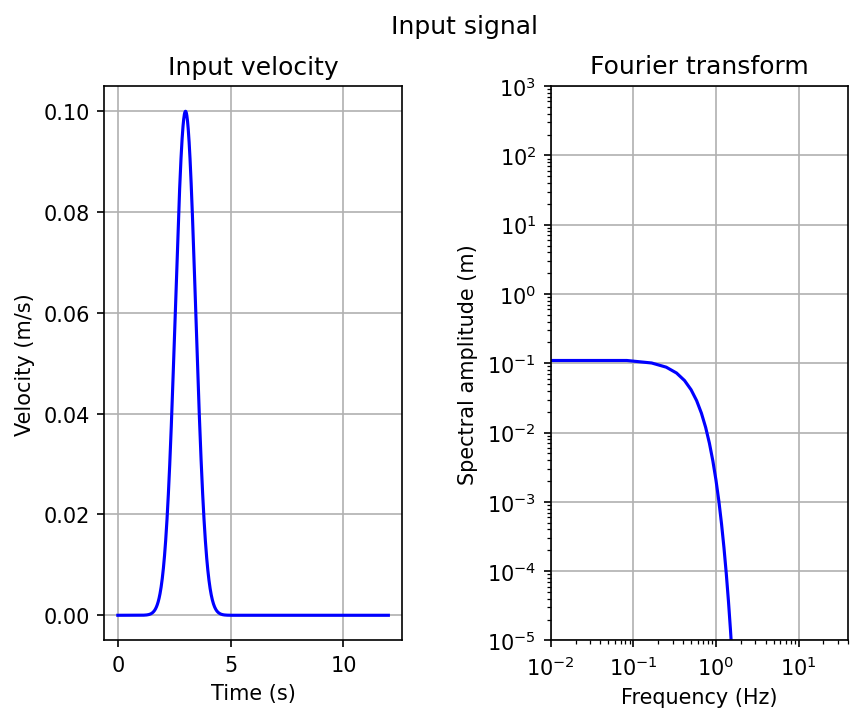

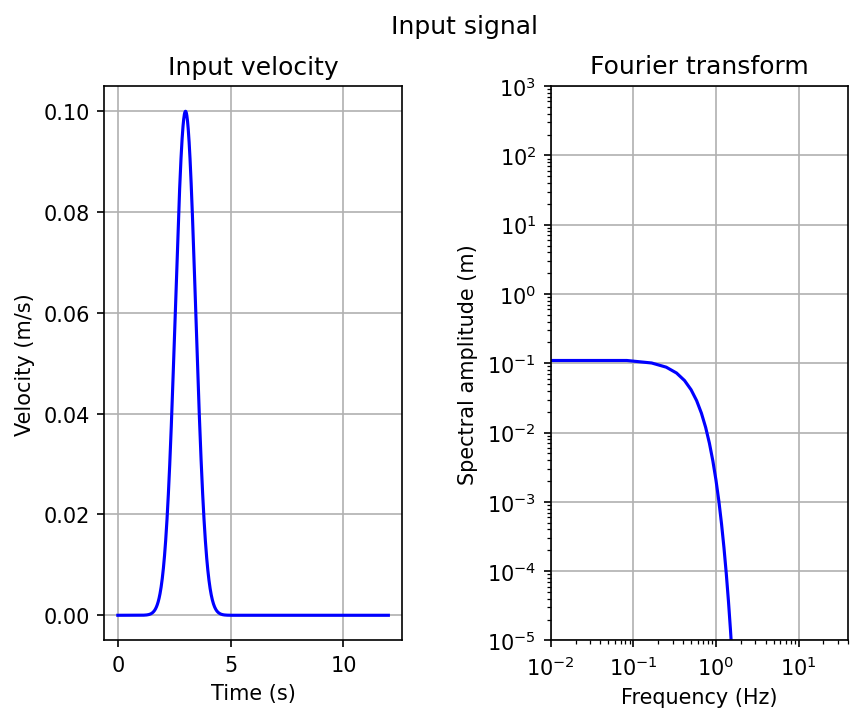

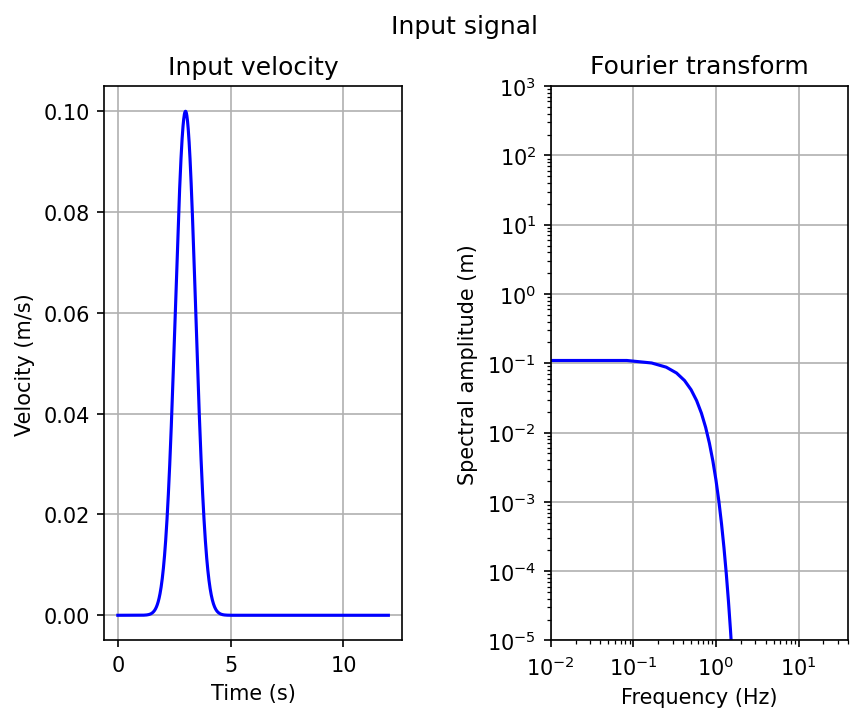

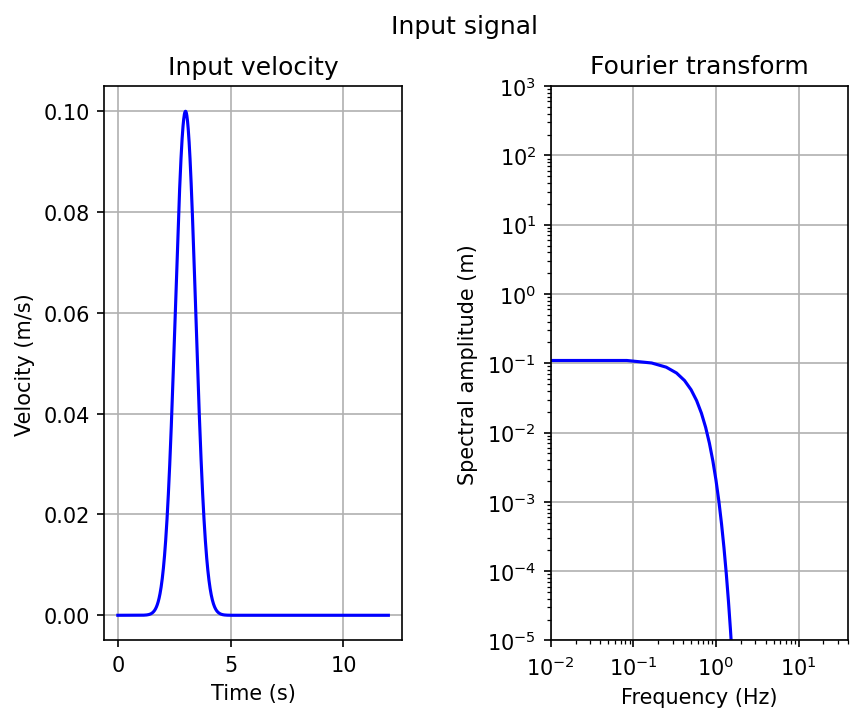

In [6]:
plot_input_signal(station_components_SEM1['time_input'], station_components_SEM1['V_input'], 'VF', fmax=fmax)
plot_input_signal(station_components_SEM2['time_input'], station_components_SEM2['V_input'], 'VF', fmax=fmax)
plot_input_signal(station_components_SEM3['time_input'], station_components_SEM3['V_input'], 'VF', fmax=fmax)
plot_input_signal(station_components_SEM4['time_input'], station_components_SEM4['V_input'], 'VF', fmax=fmax)
# XSTA, ZSTA = station_components_SEM1['X'], station_components_SEM1['Z']
# station = get_nearest_station(20, -15, XSTA, ZSTA)
# start_t = 14000
# _, _, ax_F1 = plot_input_signal(time_stations_SEM1[start_t:], station_components_SEM1['Vx'][start_t:, station], 'VF')
# line = ax_F1.get_lines()[0]
# x1, y1 = line.get_xdata(), line.get_ydata()
# _, _, ax_F2 = plot_input_signal(time_stations_SEM2[start_t:], station_components_SEM2['Vx'][start_t:, station], 'VF')
# line = ax_F2.get_lines()[0]
# x2, y2 = line.get_xdata(), line.get_ydata()

# fig, ax = plt.subplots()

# ax.plot(x1,y1, label='Angle=0°')
# ax.plot(x2,y2, label='Angle=30°')
# ax.set_xscale('log')
# ax.set_yscale('log')
# ax.set_xlabel("Frequency (Hz)")
# ax.set_ylabel("Spectral Amplitude (m)")
# ax.set_title("Fourier transforms in the ISS example with self weight")
# ax.grid(True)
# ax.legend()
# plt.show()

In [7]:
# XSTA, ZSTA = station_components_SEM1['X'], station_components_SEM1['Z']

# station = get_nearest_station(XSTA, ZSTA,0,-35)

# decalage = 1
# _, _, ax_F = plot_input_signal(time_stations_SEM1[::decalage], station_components_SEM1['Vx'][::decalage, station], 'VF', fmax=fmax)
# line = ax_F.get_lines()[0]
# x1, y1 = line.get_xdata(), line.get_ydata()

# decalage = 10
# _, _, ax_F = plot_input_signal(time_stations_SEM1[::decalage], station_components_SEM1['Vx'][::decalage, station], 'VF', fmax=fmax)
# line = ax_F.get_lines()[0]
# x2, y2 = line.get_xdata(), line.get_ydata()

# decalage = 100
# _, _, ax_F = plot_input_signal(time_stations_SEM1[::decalage], station_components_SEM1['Vx'][::decalage, station], 'VF', fmax=fmax)
# line = ax_F.get_lines()[0]
# x3, y3 = line.get_xdata(), line.get_ydata()

# decalage = 1000
# _, _, ax_F = plot_input_signal(time_stations_SEM1[::decalage], station_components_SEM1['Vx'][::decalage, station], 'VF', fmax=fmax)
# line = ax_F.get_lines()[0]
# x4, y4 = line.get_xdata(), line.get_ydata()

# decalage = 10000
# _, _, ax_F = plot_input_signal(time_stations_SEM1[::decalage], station_components_SEM1['Vx'][::decalage, station], 'VF', fmax=fmax)
# line = ax_F.get_lines()[0]
# x5, y5 = line.get_xdata(), line.get_ydata()

# fig, ax = plt.subplots()
# ax.plot(x1, y1, label='dt = 1e-5s')
# ax.plot(x2, y2, label='dt = 1e-4s')
# ax.plot(x3, y3, label='dt = 1e-3s')
# ax.plot(x4, y4, label='dt = 1e-2s')
# ax.plot(x5, y5, label='dt = 1e-1s')
# ax.set_xlim(1e-2,50)
# ax.set_ylim(1e-5, 1e-1)
# ax.set_xscale('linear')
# ax.set_yscale('log')
# ax.grid(True)
# ax.legend()
# ax.set_title(f"Comparaison des spectres")
# plt.show()


In [8]:
# plot_input_signal(station_components_SEM1['time_input'], station_components_SEM1['V_input'], 'VF', fmax=fmax, Amax=1e-2)
# decalage = 5
# print(station_components_SEM1['time_input'].size)
# print(station_components_SEM1['time_input'][::decalage].size)
# plot_input_signal(station_components_SEM1['time_input'][::decalage], station_components_SEM1['V_input'][::decalage], 'VF', fmax=fmax, Amax=1e-2)
# plt.suptitle(f"Input signal (Nouveau dt = {decalage}*Ancien dt)")
# plt.show()


### Stations

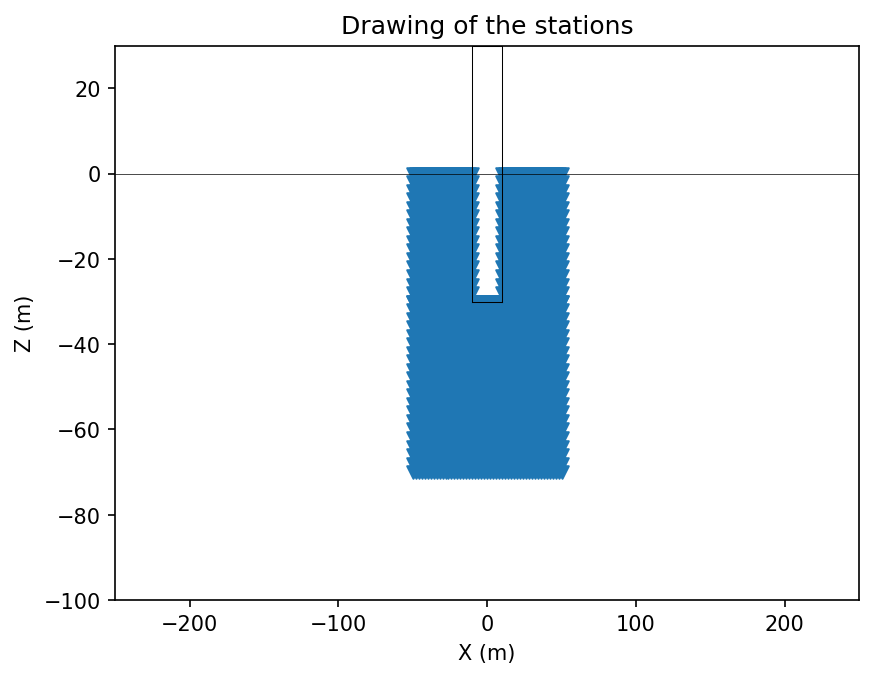

In [9]:
def show_stations(stations_components):
    """
    Function to draw the stations on a plot.
    
    Parameters:
    stations_components (dict): Dictionary containing the station components.
    """
    # Draw the plot
    XSTA, ZSTA = stations_components['X'], stations_components['Z']
    fig, ax = plt.subplots()
    draw_example(ax)
    ax.set_xlim(-250,250)
    ax.set_ylim(-100,30)
    ax.scatter(XSTA, ZSTA, marker='v')
    ax.set_title("Drawing of the stations")


show_stations(station_components_SEM3)

### Soil Properties Visualization

Mean Vs in the soil: 801.54
Mean Vs in the soil: 652.74
Mean Vs in the soil: 779.59
Mean Vs in the soil: 599.73


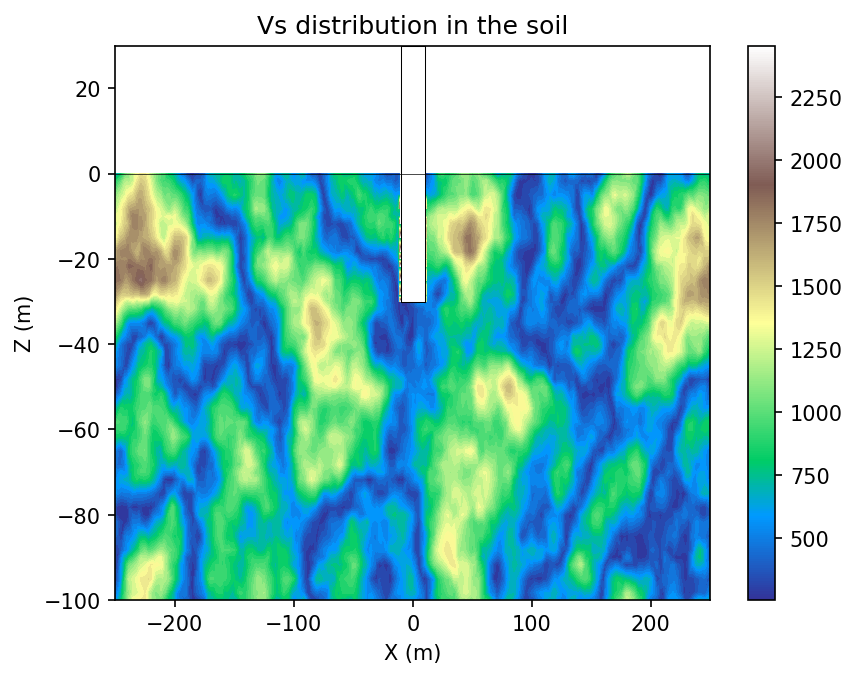

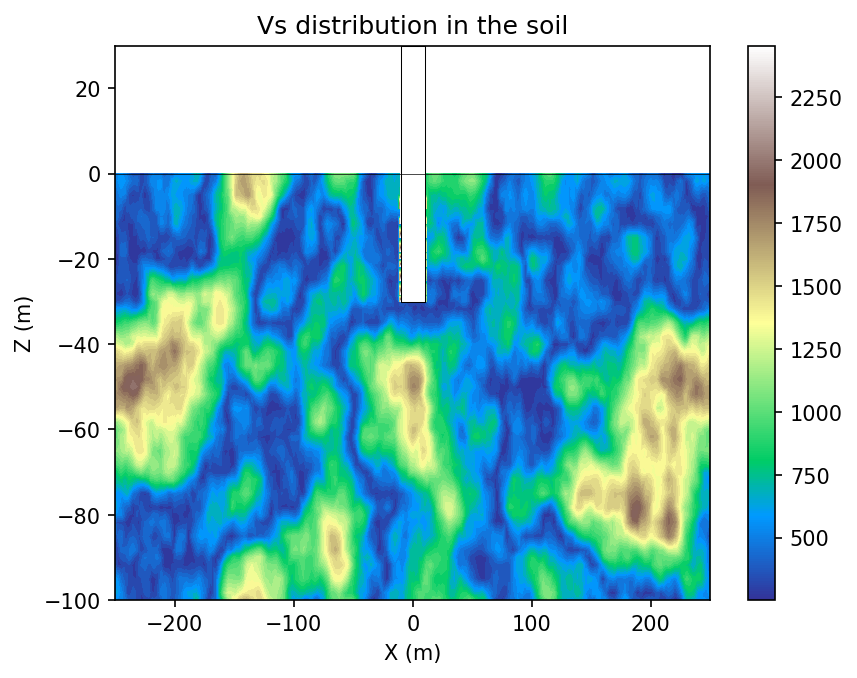

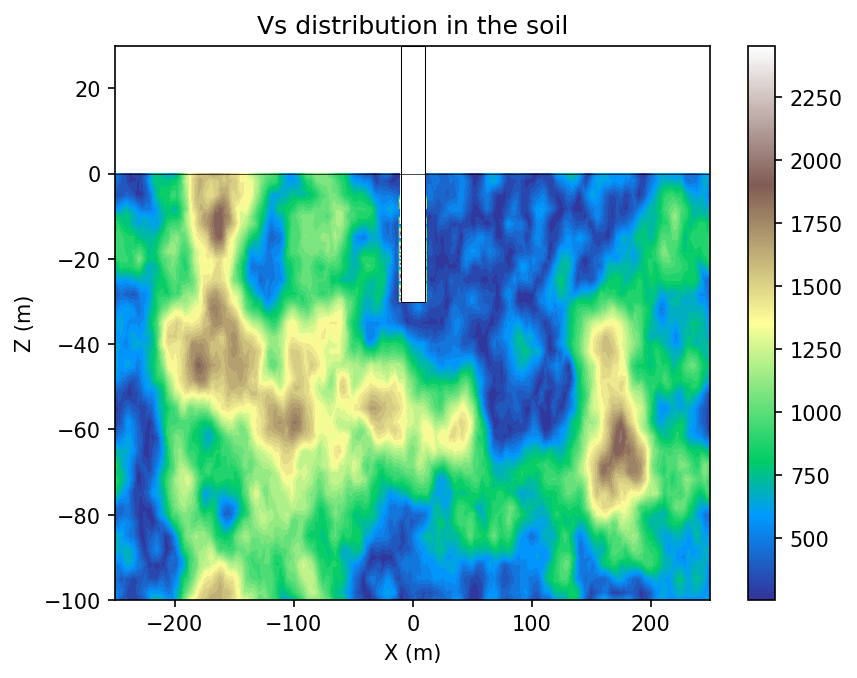

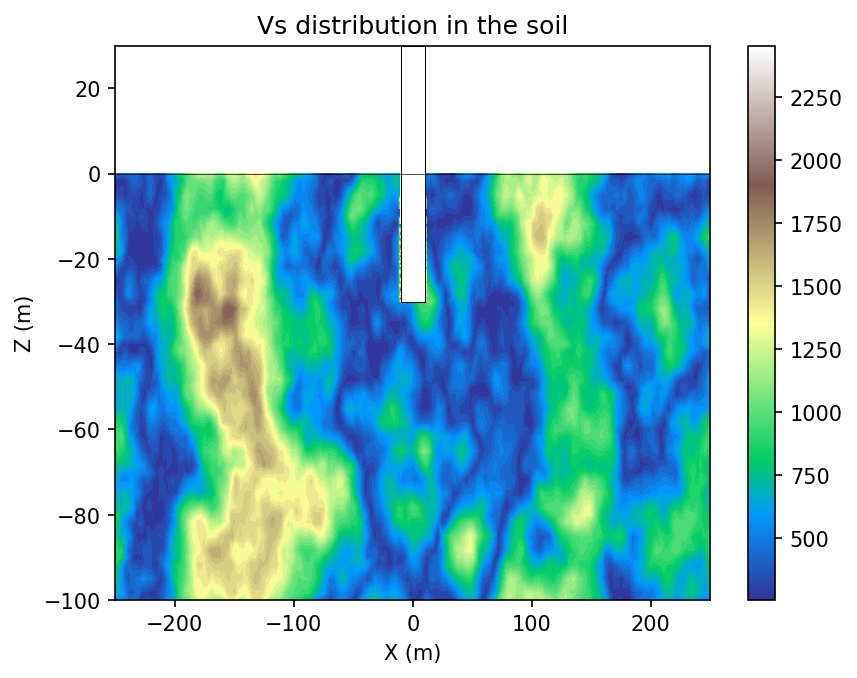

In [10]:
visualize_grid(grid_data_SEM1, component='Vs')
visualize_grid(grid_data_SEM2, component='Vs')
visualize_grid(grid_data_SEM3, component='Vs')
visualize_grid(grid_data_SEM4, component='Vs')
compute_soil_mean(grid_data_SEM1, 100, component='Vs')
compute_soil_mean(grid_data_SEM2, 100, component='Vs')
compute_soil_mean(grid_data_SEM3, 100, component='Vs')
compute_soil_mean(grid_data_SEM4, 100, component='Vs')

plt.show()

### Fourier 2D Spectrum

In [11]:
def compute_Fourier_2D(grid_data, comp):
    
    #Read grid data
    X, Z = grid_data['X'], grid_data['Z']
    soil_mask = (Z <= 0)
    structure_mask = (np.abs(Z) < 30) & (np.abs(X) < 10)
    mask = soil_mask & ~structure_mask
    X, Z, val = grid_data['X'][mask], grid_data['Z'][mask], grid_data[comp][mask]

    # Compute the Fourier Transform
    Lx, Lz = np.max(X)-np.min(X), np.max(Z)-np.min(Z)
    Nx,Nz = int(2*Lx), int(2*Lz)
    kx, kz = compute_spatial_frequencies(Lx, Lz, Nx, Nz)

    X_mesh, Z_mesh = np.linspace(X.min(), X.max(), Nx), np.linspace(Z.min(), Z.max(), Nz)
    X_mesh, Z_mesh = np.meshgrid(X_mesh, Z_mesh)
    val_interp = griddata((X,Z), val, (X_mesh, Z_mesh), method='linear')
    F = np.fft.fft2(val_interp)
    F_abs = np.abs(F)

    # Plot the Fourier Transform
    fig = plt.figure()
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect(None, zoom=0.8)
    Kx, Kz = np.meshgrid(kx, kz)
    ax.plot_trisurf(Kx.flatten(),Kz.flatten(), np.log(F_abs.flatten()), cmap='viridis')
    ax.set_xlabel('kx (1/m)')
    ax.set_ylabel('kz (1/m)')
    ax.set_zlabel('log(Fourier Amplitude)')
    ax.set_title('Fourier Transform of the grid')
    plt.show()

#compute_Fourier_2D(grid_data_SEM1, 'Vs')
# compute_Fourier_2D(grid_data_SEM2, 'Vs')




## 3) Post-Processing

### Compare Stations

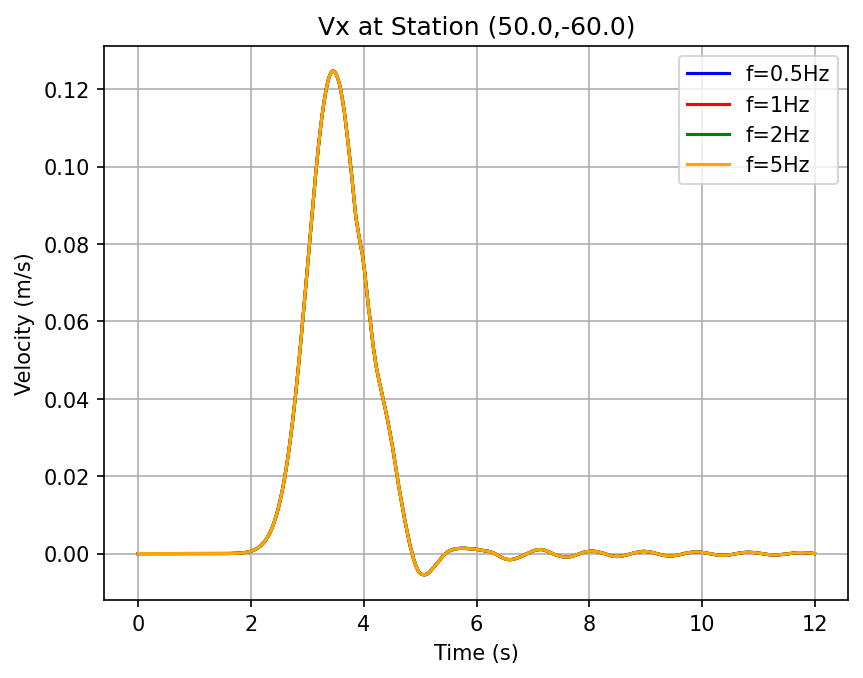

In [12]:
def plot_seismogram(ax, station, comp, time_station, station_components, color='blue', label=None):
    try :
        val = station_components[comp]
    except KeyError:
        raise Exception('Not a valid component')
    ax.plot(time_station, val[:,station], color=color, label=label)


comp = 'Vx'

fig, ax = plt.subplots()
station = get_nearest_station(50,-60,station_components_SEM1['X'], station_components_SEM1['Z'])
plot_seismogram(ax, station, comp, time_stations_SEM1, station_components_SEM1, color='blue', label='f=0.5Hz')
plot_seismogram(ax, station, comp, time_stations_SEM2, station_components_SEM2, color='red', label='f=1Hz')
plot_seismogram(ax, station, comp, time_stations_SEM3, station_components_SEM3, color='green', label='f=2Hz')
plot_seismogram(ax, station, comp, time_stations_SEM4, station_components_SEM4, color='orange', label='f=5Hz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Velocity (m/s)')
ax.set_title(f'{comp} at Station ({station_components_SEM1['X'][station]},{station_components_SEM1['Z'][station]})')
ax.legend()
ax.grid(True)
#ax.set_xlim(0,4)
# ax.set_ylim(-0.9,-0.6)
plt.show()

### Compare Interface

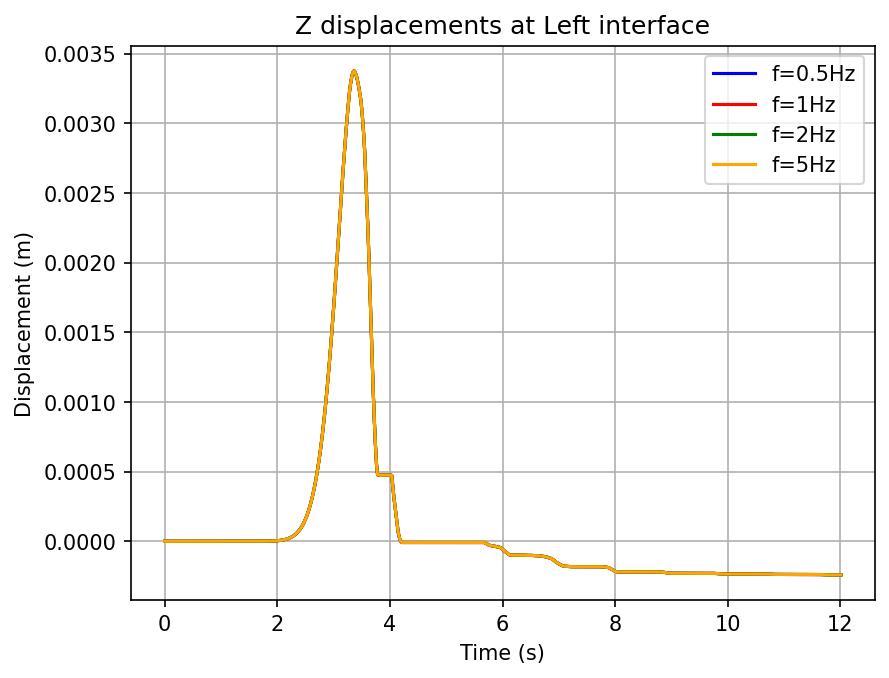

In [13]:

def plot_interface(ax, interface, comp, station, time_fault, fault_components, color='blue', label=None):
    Slip_1 = fault_components[interface]['Slip_1']
    Slip_2 = fault_components[interface]['Slip_2']
    orientation = fault_components[interface]['orientation']
    if orientation == comp:
        ax.plot(time_fault, Slip_1[station,:], color=color, label=label)
    else:
        ax.plot(time_fault, Slip_2[station,:], color=color, label=label)

    ax.set_title(f'{comp} displacements at {interface} interface')



fig, ax = plt.subplots()
station = 7
interf = 'Left'
comp = 'Z'
plot_interface(ax, interf, comp, station, time_fault_SEM1, fault_components_SEM1, color='blue', label='f=0.5Hz')
plot_interface(ax, interf, comp, station, time_fault_SEM2, fault_components_SEM2, color='red', label='f=1Hz')
plot_interface(ax, interf, comp, station, time_fault_SEM3, fault_components_SEM3, color='green', label='f=2Hz')
plot_interface(ax, interf, comp, station, time_fault_SEM4, fault_components_SEM4, color='orange', label='f=5Hz')
ax.set_xlabel('Time (s)')
ax.set_ylabel('Displacement (m)')
ax.legend()
ax.grid(True)
plt.show()

### Compare PG values and Soil Distribution

Maximum Value : 5.492e+00


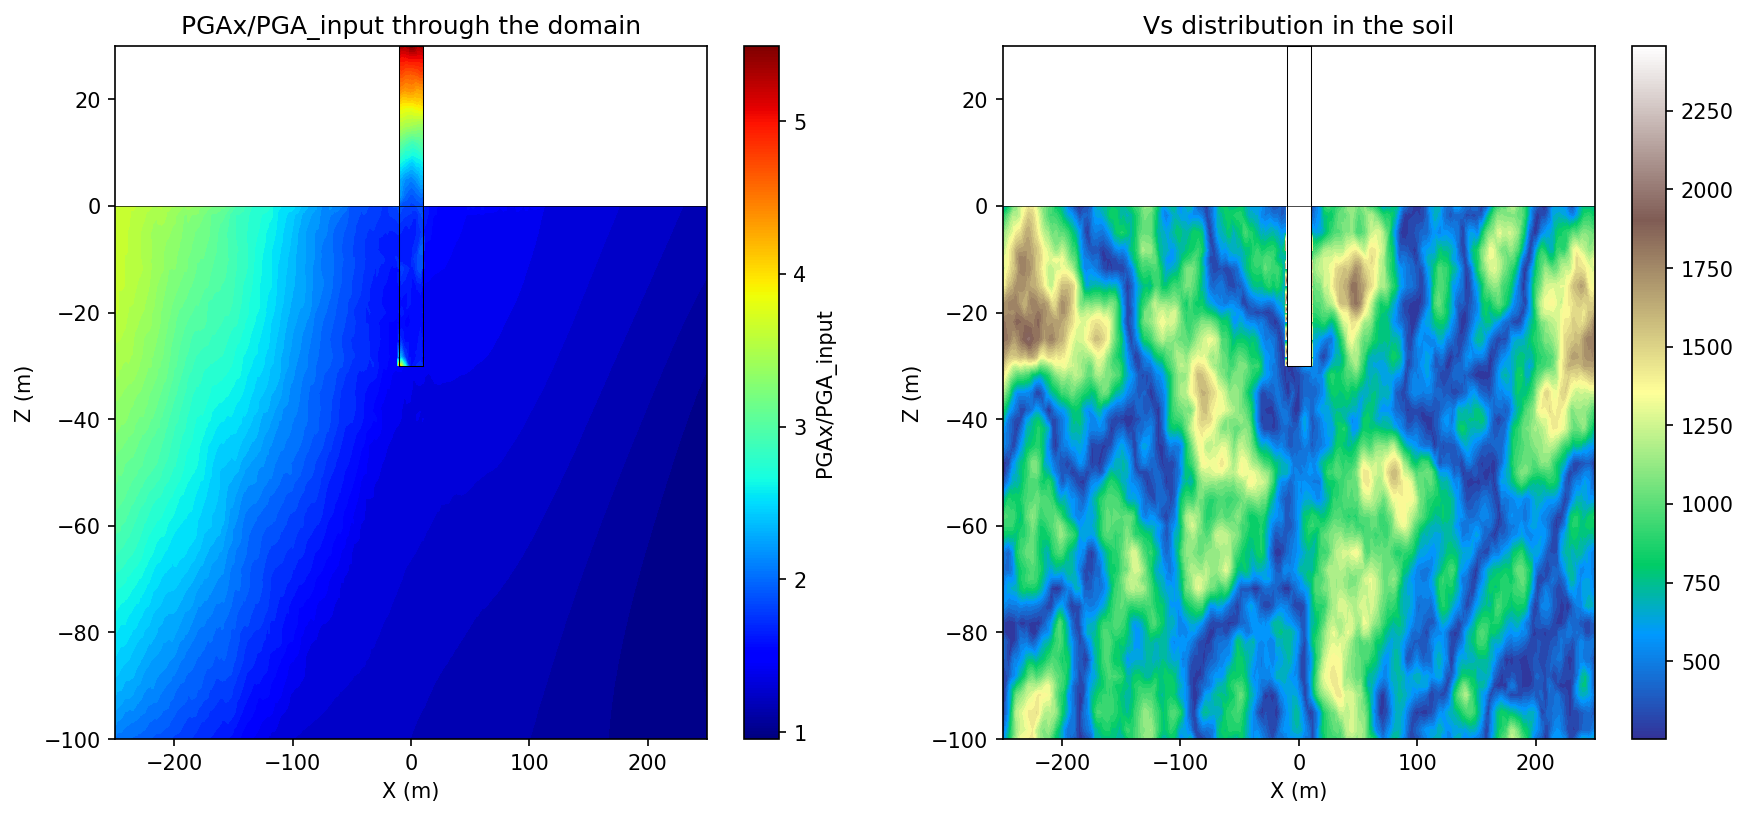

In [14]:
def plot_peak_values(station_components, grid_data, comp, norm=None, ratio_mode=None, ax=None):
    if comp not in ['PGVx', 'PGVz', 'PGAx', 'PGAz']:
        raise Exception('Not a valid component for peak values')
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
    cmap = 'jet'
    X_snap = station_components['X_snap']
    Z_snap = station_components['Z_snap']
    Val = station_components[comp][:].copy()
    title_plot = f'{comp} through the domain'
    title_cbar = f'{comp}'
    if ratio_mode=='PGA':
        PGA_input = np.max(station_components['A_input'])
        Val = Val/PGA_input
        title_plot = f'{comp}/PGA_input through the domain'
        title_cbar = f'{comp}/PGA_input'
    elif ratio_mode=='PGV':
        PGV_input = np.max(station_components['V_input'])
        Val = Val/PGV_input
        title_plot = f'{comp}/PGV_input through the domain'
        title_cbar = f'{comp}/PGV_input'
    elif ratio_mode=='Vs':
        Vs = grid_data['Vs']
        X_grid, Z_grid = grid_data['X_grid'], grid_data['Z_grid']
        for i in range(Val.size):
            index = get_nearest_station(X_snap[i],Z_snap[i],X_grid,Z_grid)
            Val[i] = Val[i]/Vs[index]
        title_plot = f'{comp}/Vs through the domain'
        title_cbar = f'{comp}/Vs'
    soil_mask = (Z_snap <= 0)
    structure_mask = (np.abs(Z_snap) < 30) & (np.abs(X_snap) < 10)
    if norm is None:
        norm = plt.Normalize(vmin=np.min(Val), vmax= np.max(Val))

    print(f"Maximum Value : {np.max(Val):.3e}")

    ax.tricontourf(X_snap[structure_mask], Z_snap[structure_mask], Val[structure_mask], levels=50, cmap=cmap, norm=norm)
    ax.tricontourf(X_snap[soil_mask], Z_snap[soil_mask], Val[soil_mask], levels=50, cmap=cmap, norm=norm)
    fig.colorbar(ScalarMappable(norm=norm,cmap=cmap), ax=ax, label=title_cbar)
    draw_example(ax)
    ax.set_xlim(-250,250)
    ax.set_ylim(-100,30)
    ax.set_title(title_plot)

comp = 'PGAx'
norm = plt.Normalize(vmin=0, vmax=1)
norm=None
ratio_mode='PGA'
station = station_components_SEM4
grid = grid_data_SEM1
fig, [ax1, ax2] = plt.subplots(1,2, figsize=(14, 6))
visualize_grid(grid, component='Vs', ax=ax2)
plot_peak_values(station, grid, comp, norm=norm, ratio_mode=ratio_mode, ax=ax1)
#fig.suptitle('f = 5Hz')



### TF

2.981427174975562 93.52673732355072
2.981427174975562 93.52673732355072
2.981427174975562 93.52673732355072
2.981427174975562 93.52673732355072


Text(0, 0.5, 'Gain')

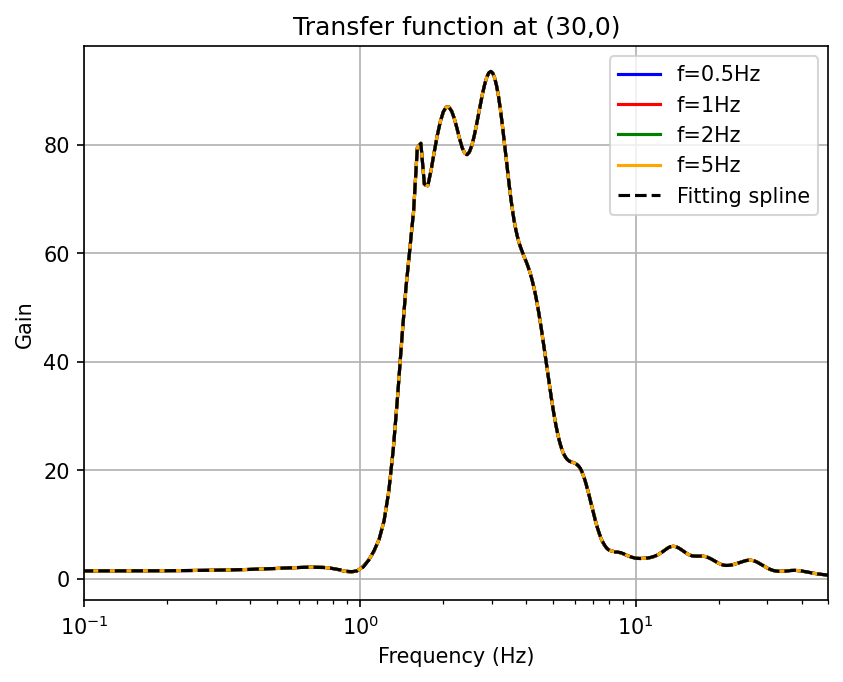

In [15]:
freq = station_components_SEM1['freq_input']
# FFT_input1, FFT_sta1 = station_components_SEM1['FFT_input'], station_components_SEM1['FFT_sta']
# FFT_input2, FFT_sta2 = station_components_SEM2['FFT_input'], station_components_SEM2['FFT_sta']
# FFT_input3, FFT_sta3 = station_components_SEM3['FFT_input'], station_components_SEM3['FFT_sta']
# FFT_input4, FFT_sta4 = station_components_SEM4['FFT_input'], station_components_SEM4['FFT_sta']
TF1 = station_components_SEM1['TF']
TF2 = station_components_SEM2['TF']
TF3 = station_components_SEM3['TF']
TF4 = station_components_SEM4['TF']

print(freq[np.argmax(TF1)], TF1[np.argmax(TF1)])
print(freq[np.argmax(TF2)], TF2[np.argmax(TF2)])
print(freq[np.argmax(TF3)], TF3[np.argmax(TF3)])
print(freq[np.argmax(TF4)], TF4[np.argmax(TF4)])



spline_TF = []
for i in range(TF1.size):
    mean = np.mean([TF1[i], TF2[i], TF3[i], TF4[i]])
    spline_TF.append(mean)

spline_TF = np.array(spline_TF)

from scipy.interpolate import UnivariateSpline
spline = UnivariateSpline(freq, spline_TF, s=1)

alpha= 1

plt.plot(freq, TF1, color='blue', label='f=0.5Hz', alpha=alpha)
plt.plot(freq, TF2, color='red', label='f=1Hz', alpha=alpha)
plt.plot(freq, TF3, color='green', label='f=2Hz', alpha=alpha)
plt.plot(freq, TF4, color='orange', label='f=5Hz', alpha=alpha)
plt.plot(freq, spline(freq), color='black', label='Fitting spline', ls='--')
plt.xscale('log')
#plt.yscale('log')
plt.grid(True)
plt.xlim(0.1,50)
#plt.ylim(1e-1,8.5)
plt.legend()
plt.title('Transfer function at (30,0)')
plt.xlabel("Frequency (Hz)")
plt.ylabel("Gain")

### Compare deformed structure

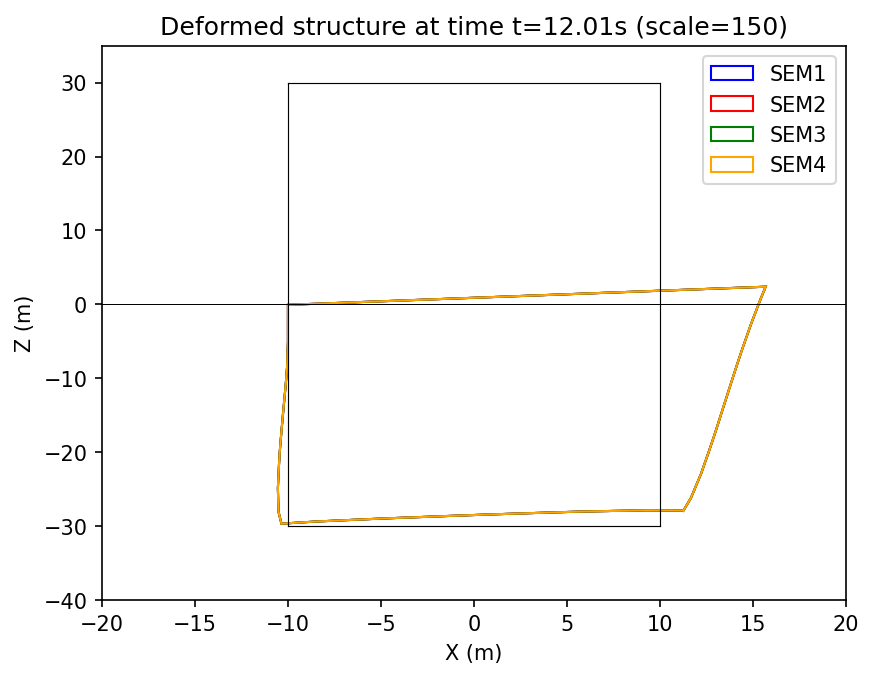

In [16]:

def compute_disp_fault(t, comp, fault_components):
    X_comp = np.array([])
    Z_comp = np.array([])
    Slip_1 = fault_components[comp]['Slip_1']
    Slip_2 = fault_components[comp]['Slip_2']
    S1_dir = fault_components[comp]['orientation']
    if S1_dir=='X':
        X_add = vector_orientations[comp][0]*Slip_1[:,t]
        Z_add= vector_orientations[comp][1]*Slip_2[:,t]
    else :
        X_add = vector_orientations[comp][0]*Slip_2[:,t]
        Z_add = vector_orientations[comp][1]*Slip_1[:,t]
    
    X_comp = np.concatenate([X_comp, X_add])
    Z_comp = np.concatenate([Z_comp, Z_add])
    return X_comp, Z_comp

def compute_deformation(t, scale, fault_components):
    X_coord, Z_coord = np.array([]), np.array([])
    X_comp, Z_comp = np.array([]), np.array([])
    X_new, Z_new = np.array([]), np.array([])
    for c in fault_components.keys():
        X_coord_c = fault_components[c]['X_coord']
        Z_coord_c = fault_components[c]['Z_coord']
        X_comp_c, Z_comp_c = compute_disp_fault(t, c, fault_components)
        X_new_c = X_coord_c + scale*X_comp_c
        Z_new_c = Z_coord_c + scale*Z_comp_c
        if c=="Left":
            X_new_c = np.flip(X_new_c)
            Z_new_c = np.flip(Z_new_c)
        X_coord = np.concatenate([X_coord, X_coord_c])
        Z_coord = np.concatenate([Z_coord, Z_coord_c])
        X_comp = np.concatenate([X_comp, X_comp_c])
        Z_comp = np.concatenate([Z_comp, Z_comp_c])
        X_new = np.concatenate([X_new, X_new_c])
        Z_new = np.concatenate([Z_new, Z_new_c])
    return X_coord, Z_coord, X_comp, Z_comp, X_new, Z_new

def draw_fault_deformation(t, ax, fault_components, scale=100, color='red', label=None):
    time = time_fault_SEM1[t]
    ax.set_title(f"Deformed structure at time t={time:.2f}s (scale={scale:.0f})")
    draw_example(ax)
    X_coord, Z_coord, X_comp, Z_comp, X_new, Z_new = compute_deformation(t, scale, fault_components)
    #ax.quiver(X_coord, Z_coord, X_comp, Z_comp, scale=1/scale, scale_units='xy', angles='xy')
    ax.fill(X_new, Z_new, facecolor='none', edgecolor=color, label=label)

fig = plt.figure()
ax = fig.add_subplot(1,1,1)
draw_fault_deformation(-1, ax, fault_components_SEM1,scale=150, color='blue', label="SEM1")
draw_fault_deformation(-1, ax, fault_components_SEM2,scale=150, color='red', label="SEM2")
draw_fault_deformation(-1, ax, fault_components_SEM3,scale=150, color='green', label="SEM3")
draw_fault_deformation(-1, ax, fault_components_SEM4,scale=150, color='orange', label="SEM4")

ax.legend()
ax.set_xlim([-20,20])
ax.set_ylim([-40,35])
plt.show()

### Deformed Structure Animation

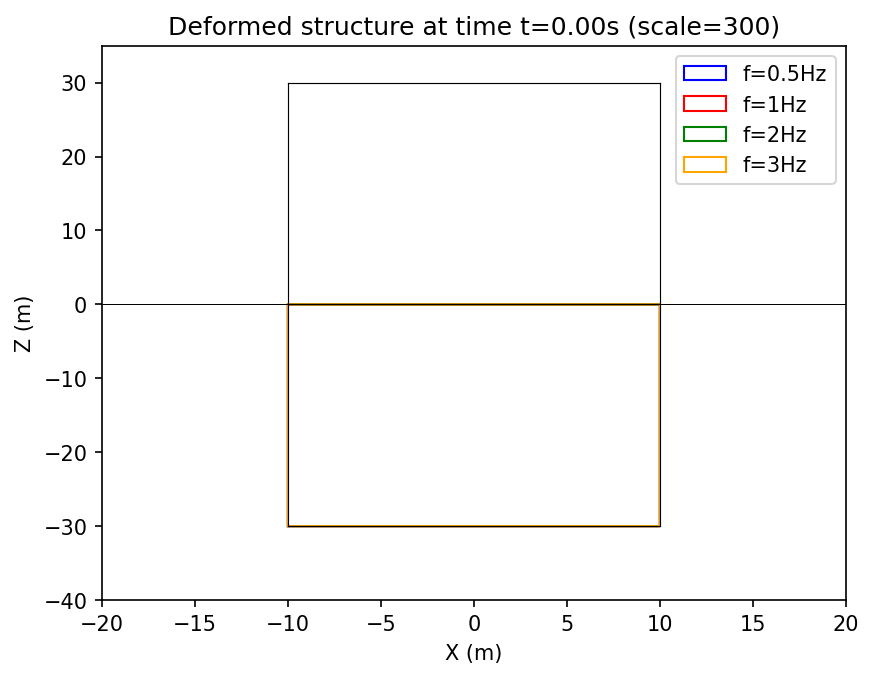

In [17]:
fig, ax = plt.subplots()

def animate(t):
    ax.cla()
    scale = 300
    draw_fault_deformation(t, ax, fault_components_SEM1, scale=scale, color='blue', label="f=0.5Hz")
    draw_fault_deformation(t, ax, fault_components_SEM2, scale=scale, color='red', label="f=1Hz")
    draw_fault_deformation(t, ax, fault_components_SEM3, scale=scale, color='green', label="f=2Hz")
    draw_fault_deformation(t, ax, fault_components_SEM4, scale=scale, color='orange', label="f=3Hz")
    ax.legend()
    ax.set_xlim([-20,20])
    ax.set_ylim([-40,35])

writer = anim.PillowWriter(60)
anim.FuncAnimation(fig, animate, range(0,len(time_fault_SEM1)//3,5)).save("Structure_Anim.gif", writer=writer)

### Field animation

In [18]:
# Functions definition
def create_path(SEM,comp,t):
    n = f"{t:03d}"
    path = SEM.directory + f'v{comp}_{n}_sem2d.dat'
    return path

def load_field(SEM, comp, t):
    X_Coord, Z_Coord = SEM.mdict["coord"][:,0] , SEM.mdict["coord"][:,1]
    path = create_path(SEM,comp, t)
    if not os.path.exists(path):
        raise FileNotFoundError(f"File {path} does not exist.")
    field = SEM.readField(path)
    return X_Coord, Z_Coord, field


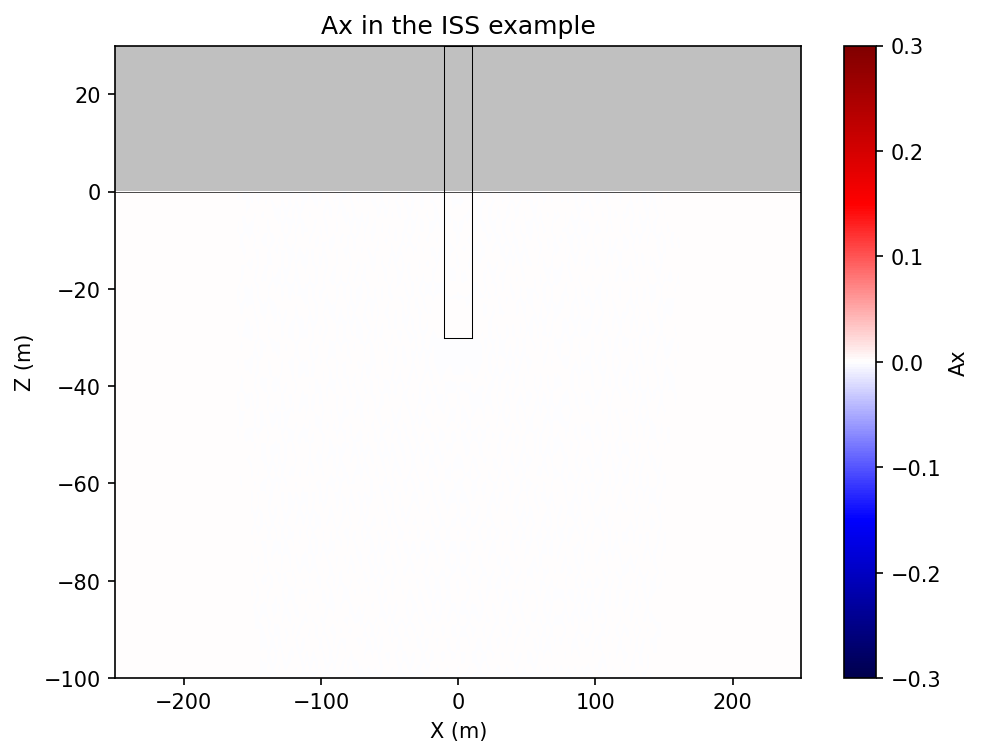

KeyboardInterrupt: 

In [19]:
#fig, [ax1, ax2, ax3] = plt.subplots(1,3, figsize=(15,5))
fig = plt.figure()
# gs = plt.GridSpec(2, 2, figure=fig)
# ax1 = fig.add_subplot(gs[0, 0])
# ax2 = fig.add_subplot(gs[0, 1])
# ax3 = fig.add_subplot(gs[1, :])
ax3 = fig.add_subplot(1,1,1)
station_components = station_components_SEM1
time_stations = time_stations_SEM1
comp = 'Ax'
max_val = 0.3
norm = plt.Normalize(vmin=-max_val, vmax=max_val)
cmap = 'seismic'
# cbar = fig.colorbar(ScalarMappable(norm=norm,cmap=cmap), ax=ax3, label=f'{comp}')
cbar = fig.colorbar(ScalarMappable(norm=norm,cmap=cmap), ax=ax3, label=f'{comp}')



indic = 'log'



def plot_field(ax,X,Z,field):
    #ax.cla()
    #norm = plt.Normalize(vmin=np.min(field), vmax= np.max(field))
    ax.tricontourf(X, Z, field, levels=50, cmap=cmap, norm=norm)
    cbar.update_normal(ScalarMappable(norm=norm,cmap=cmap))
    draw_example(ax)
    ax.set_xlim(-250,250)
    ax.set_ylim(-100,30)
    ax.set_title(f'{comp} in the ISS example')
    plt.show()

def compute_log_ratio(val1, val2):
    epsilon = 1e-6
    ratio = np.log10(val1/val2)
    return np.nan_to_num(ratio, nan=0.0, posinf=max_val, neginf=-max_val)

def compute_relative_difference(val1, val2):
    epsilon = 1e-6
    return np.nan_to_num(np.abs((val1 - val2) / (val2 + epsilon)), nan=0.0, posinf=max_val, neginf=0.0)

def compute_relative_difference_test(val1, val2):
    epsilon = 1e-4
    return np.log10((val1 + epsilon) / (val2 + epsilon) + epsilon)

def animate_field(t, station_components, comp):
    ax3.cla()
    ax3.set_facecolor('silver')
    #ax3.fill([-10,10,10,-10],[-30,-30,30,30], color='white')
    X, Z, field = station_components['X_snap'], station_components['Z_snap'], station_components[comp][:,t]
    soil_mask = (Z <= 0)
    structure_mask = (np.abs(Z) < 30) & (np.abs(X) < 10)
    plot_field(ax3, X[soil_mask], Z[soil_mask], field[soil_mask])
    plot_field(ax3, X[structure_mask], Z[structure_mask], field[structure_mask])
    ax3.set_title(f'{comp} in the ISS example (t={1e-2*t:.2f}s)')
    #plot_field(ax3, X[structure_mask], Z[structure_mask], field[structure_mask])
    #fig.tight_layout()

# visualize_grid(grid_data_SEM1, component='Vs', ax=ax1)
# visualize_grid(grid_data_SEM2, component='Vs', ax=ax2)
fig.tight_layout()
# def animate_diff(t):
#     ax3.cla()
#     ax3.set_facecolor('silver')
#     X, Z, Vx_1 = load_field(SEM2, 'x', t)
#     _, _, Vx_2 = load_field(SEM3, 'x', t)
#     ratio = compute_log_ratio(Vx_1, Vx_2)
#     diff = compute_relative_difference_test(Vx_1, Vx_2)
#     mask = np.isnan(ratio) | np.isinf(ratio)
#     X, Z, ratio = X[~mask], Z[~mask], ratio[~mask]
#     comp = ratio
#     soil_mask = (Z <= 0)
#     structure_mask = (np.abs(Z) < 30) & (np.abs(X) < 10)
#     plot_field(ax3, X[soil_mask], Z[soil_mask], comp[soil_mask])
#     plot_field(ax3, X[structure_mask], Z[structure_mask], comp[structure_mask])
#     fig.tight_layout()
    

anim.FuncAnimation(fig, lambda t : animate_field(t, station_components_SEM1, 'Ax_snap'), range(0, len(time_stations_SEM1)-1, 5)).save("Test.gif", writer=writer)